# 🔢 Campaign Viability Analyzer — Tabular Pipeline Notebook
### Notebook 03: ColumnTransformer (StandardScaler + OneHotEncoder)

---

**Author:** Aarsh Bhatnagar  
**Input:** `data/kickstarter_clean.csv` + `artifacts/train_idx.npy`, `test_idx.npy` (from Notebook 02)  
**Outputs:** `artifacts/preprocessor.pkl` · `artifacts/X_train_tabular.npz` · `artifacts/X_test_tabular.npz` · `artifacts/tabular_feature_names.npy`

---

> **How to read this notebook:**  
> Every code cell is preceded by a markdown cell explaining **What**, **Why**, and **What to look for**.  
> This notebook scales numerical columns and one-hot encodes categorical columns —  
> using the **exact same train/test split** locked in Notebook 02.


---
## Section 0 — Imports & Configuration

**What:** Load libraries, define all parameters in one place.  
**Why:** Same rule as Notebooks 01 and 02. This notebook does **NOT** create a new train/test split — it loads the exact indices saved by Notebook 02. This is non-negotiable: a second split here would put different rows in train vs test compared to the TF-IDF matrices, silently breaking the fusion step in Notebook 04.

**A deliberate design decision baked into this CONFIG:** `launch_month` and `launch_day_of_week` are placed in `categorical_cols`, not `numerical_cols`. Month and day-of-week are **cyclical categories**, not a continuum — December (12) and January (1) are calendar-adjacent but numerically far apart. Scaling them with StandardScaler would teach the model a fake linear relationship that doesn't reflect reality. One-hot encoding treats each month/day as its own independent category, which is correct. `launch_year` stays numerical — it's a genuine trend variable (platform growth over time), not cyclical.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import joblib
import scipy.sparse
import warnings

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

warnings.filterwarnings('ignore')

# ── Visual style ──────────────────────────────────────────────────────────────
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='muted')

# ── Configuration ─────────────────────────────────────────────────────────────
CONFIG = {
    # Input
    'clean_data_path' : 'data/kickstarter_clean.csv',
    'artifacts_dir'    : 'artifacts/',
    'plots_dir'        : 'plots/',
    'target_col'       : 'target',

    # ── Numerical columns ──
    # Truly continuous/ordinal — get StandardScaler.
    'numerical_cols' : [
        'usd_goal_real',
        'campaign_duration_days',
        'name_length',
        'launch_year',
    ],

    # ── Categorical columns ──
    # launch_month and launch_day_of_week live HERE (not numerical) —
    # cyclical categories, not a continuum. See markdown above for why.
    'categorical_cols' : [
        'category',
        'main_category',
        'currency',
        'country',
        'launch_month',
        'launch_day_of_week',
    ],
}

os.makedirs(CONFIG['artifacts_dir'], exist_ok=True)
os.makedirs(CONFIG['plots_dir'],     exist_ok=True)

print("✅ Libraries loaded")
print(f"   Numerical columns   : {CONFIG['numerical_cols']}")
print(f"   Categorical columns : {CONFIG['categorical_cols']}")
print("✅ Output directories ready")


✅ Libraries loaded
   Numerical columns   : ['usd_goal_real', 'campaign_duration_days', 'name_length', 'launch_year']
   Categorical columns : ['category', 'main_category', 'currency', 'country', 'launch_month', 'launch_day_of_week']
✅ Output directories ready


---
## Section 1 — Load Clean Dataset + Locked Split Indices

**What:** Load the clean CSV, then load `train_idx`/`test_idx` saved by Notebook 02 — do **NOT** create a new split.  
**Why:** This is the single most important rule across all notebooks. Notebook 02's TF-IDF matrices were built using a specific row order. If this notebook splits differently, row 5 here might be row 5 in Notebook 02's *test* set. Fusion in Notebook 04 would then combine mismatched rows — silent, catastrophic data corruption that produces a model that looks fine in metrics but is meaningless.

**What to look for:** `train_idx` length should be 265,266. `test_idx` should be 66,317 — matching Notebook 02 exactly. The split-consistency check verifies this by comparing target values, not just lengths.


In [2]:
df = pd.read_csv(CONFIG['clean_data_path'])
print(f"  Clean dataset shape : {df.shape}")

train_idx = np.load(f"{CONFIG['artifacts_dir']}train_idx.npy")
test_idx  = np.load(f"{CONFIG['artifacts_dir']}test_idx.npy")

print(f"  Loaded train_idx    : {len(train_idx):,} indices")
print(f"  Loaded test_idx     : {len(test_idx):,} indices")

# Reconstruct the EXACT same train/test split as Notebook 02
df_train = df.iloc[train_idx].reset_index(drop=True)
df_test  = df.iloc[test_idx].reset_index(drop=True)

y_train_loaded = np.load(f"{CONFIG['artifacts_dir']}y_train.npy")
y_test_loaded  = np.load(f"{CONFIG['artifacts_dir']}y_test.npy")

# Verify our reconstructed split matches the saved labels exactly
match_train = np.array_equal(df_train[CONFIG['target_col']].values, y_train_loaded)
match_test  = np.array_equal(df_test[CONFIG['target_col']].values,  y_test_loaded)

print(f"\n  ── Split consistency check ────────────────────────────")
print("  " + ("✅" if match_train else "❌") +
      f" Train target matches Notebook 02's y_train.npy: {match_train}")
print("  " + ("✅" if match_test else "❌") +
      f" Test  target matches Notebook 02's y_test.npy : {match_test}")

if not (match_train and match_test):
    raise ValueError("Split mismatch detected — STOP. Do not proceed until this is fixed.")

print(f"\n  ✅ Confirmed: this notebook uses the EXACT SAME split as Notebook 02")
print(f"     Train: {len(df_train):,} rows   Test: {len(df_test):,} rows")


  Clean dataset shape : (331583, 14)
  Loaded train_idx    : 265,266 indices
  Loaded test_idx     : 66,317 indices

  ── Split consistency check ────────────────────────────
  ✅ Train target matches Notebook 02's y_train.npy: True
  ✅ Test  target matches Notebook 02's y_test.npy : True

  ✅ Confirmed: this notebook uses the EXACT SAME split as Notebook 02
     Train: 265,266 rows   Test: 66,317 rows


---
## Section 2 — Numerical Feature Audit (Before Scaling)

**What:** Inspect the distributions of the 4 numerical columns before applying StandardScaler.  
**Why:** StandardScaler transforms each column to mean=0, std=1. `usd_goal_real` is heavily right-skewed — StandardScaler still works on skewed data, but it's worth seeing the scale differences **before** scaling so the transformation actually means something to you.

**What to look for:** `usd_goal_real` ranges from $0.01 to $166M — a wildly different scale than `launch_year` (2009-2017) or `name_length` (0-85). This is exactly why scaling matters: without it, `usd_goal_real` would dominate the model simply because its raw numbers are bigger, not because it's more predictive.


In [3]:
num_cols = CONFIG['numerical_cols']
print("  ── Raw Scale Comparison (why scaling is necessary) ────")
for col in num_cols:
    print(f"  {col:<25} min={df_train[col].min():>14,.2f}  "
          f"max={df_train[col].max():>14,.2f}  "
          f"mean={df_train[col].mean():>10,.2f}")


  ── Raw Scale Comparison (why scaling is necessary) ────
  usd_goal_real             min=          0.01  max=166,361,390.71  mean= 40,175.03
  campaign_duration_days    min=          1.00  max=         91.00  mean=     32.96
  name_length               min=          0.00  max=         85.00  mean=     34.22
  launch_year               min=      2,009.00  max=      2,017.00  mean=  2,014.18


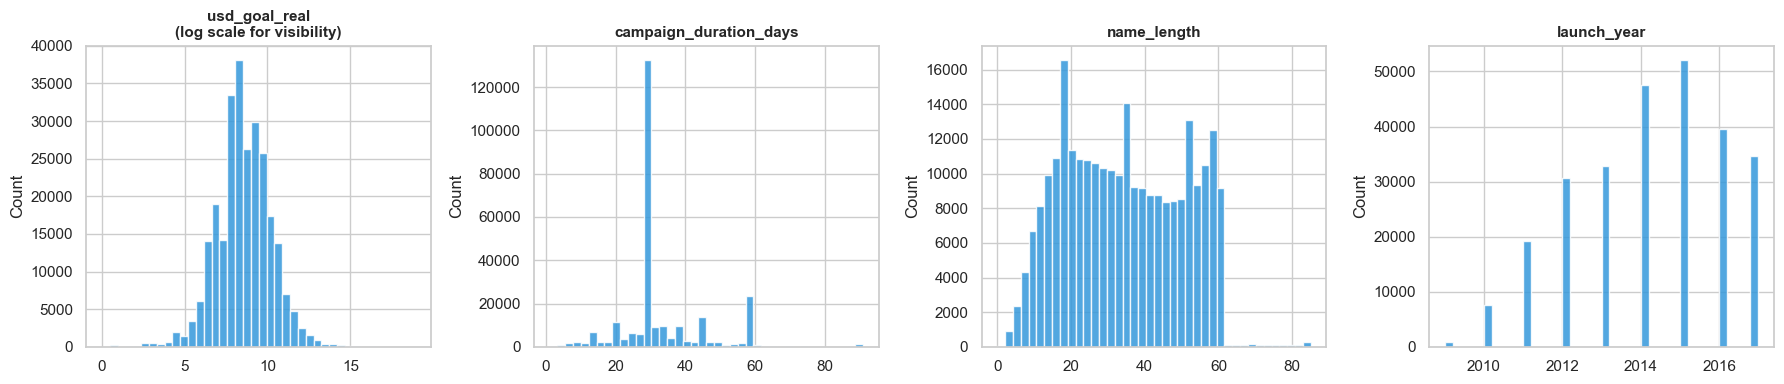

  ✅ Plot saved: plots/14_numerical_features_before_scaling.png


In [4]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for i, col in enumerate(num_cols):
    data_to_plot = df_train[col]
    if col == 'usd_goal_real':
        data_to_plot = np.log1p(data_to_plot)  # log scale for visibility only
        title_suffix = '\n(log scale for visibility)'
    else:
        title_suffix = ''
    axes[i].hist(data_to_plot, bins=40, color='#3498db',
                 edgecolor='white', alpha=0.85)
    axes[i].set_title(f'{col}{title_suffix}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.savefig(f"{CONFIG['plots_dir']}14_numerical_features_before_scaling.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("  ✅ Plot saved: plots/14_numerical_features_before_scaling.png")


---
## Section 3 — Categorical Feature Audit (Cardinality Recap)

**What:** Confirm cardinality of all 6 categorical columns before one-hot encoding, including the two cyclical time features moved here from numerical.  
**Why:** Cardinality directly determines how many columns OneHotEncoder produces. `category` alone (159 unique values) creates 159 binary columns. Total expected output: 159+15+14+23+12+7 = **230 columns**.

This matters because more columns mean more memory (still trivial here, sparse) and more risk of overfitting per category with too few examples. The rare-category check below confirms we don't have any categories with dangerously few training examples.

**What to look for:** Total one-hot dimension count should match the 230 calculation. No categories should have fewer than ~10 training examples.


In [5]:
cat_cols = CONFIG['categorical_cols']
total_onehot_dims = 0

print("  ── Cardinality of each categorical column ─────────────")
for col in cat_cols:
    n_unique = df_train[col].nunique()
    total_onehot_dims += n_unique
    print(f"  {col:<22} {n_unique:>4} unique values  → {n_unique} one-hot columns")

print(f"\n  ── Expected total one-hot output dimensions ───────────")
print(f"  {total_onehot_dims} categorical columns  +  "
      f"{len(num_cols)} scaled numerical columns")
print(f"  = {total_onehot_dims + len(num_cols)} total feature dimensions")


  ── Cardinality of each categorical column ─────────────
  category                159 unique values  → 159 one-hot columns
  main_category            15 unique values  → 15 one-hot columns
  currency                 14 unique values  → 14 one-hot columns
  country                  23 unique values  → 23 one-hot columns
  launch_month             12 unique values  → 12 one-hot columns
  launch_day_of_week        7 unique values  → 7 one-hot columns

  ── Expected total one-hot output dimensions ───────────
  230 categorical columns  +  4 scaled numerical columns
  = 234 total feature dimensions


In [6]:
# Check for rare categories that might cause instability
print("  ── Rare category check (< 10 occurrences in training) ──")
for col in cat_cols:
    counts = df_train[col].value_counts()
    rare = counts[counts < 10]
    if len(rare) > 0:
        print(f"  ⚠️  {col}: {len(rare)} categories with < 10 examples — "
              f"{rare.index.tolist()[:5]}{'...' if len(rare) > 5 else ''}")
    else:
        print(f"  ✅ {col}: no categories with < 10 examples")


  ── Rare category check (< 10 occurrences in training) ──
  ✅ category: no categories with < 10 examples
  ✅ main_category: no categories with < 10 examples
  ✅ currency: no categories with < 10 examples
  ✅ country: no categories with < 10 examples
  ✅ launch_month: no categories with < 10 examples
  ✅ launch_day_of_week: no categories with < 10 examples


---
## Section 4 — Build the ColumnTransformer Pipeline

**What:** Construct the preprocessing pipeline that scales numerical columns and one-hot encodes categorical ones, all in a single, reusable transformer object.  
**Why:** Two deliberate design decisions baked in here:

**1. `SimpleImputer` added to both branches** — even though Notebook 01's checklist confirmed zero nulls in training data. Why add it anyway? This preprocessor gets reused in Notebook 07 for **live inference** — a real user might leave a field blank. Without an imputer, one missing value crashes the entire prediction. With it: missing numerical → filled with median, missing categorical → filled with most frequent category. Defensive coding for production, not just historical data.

**2. `handle_unknown='ignore'` on OneHotEncoder** — if a future campaign comes from a country not seen in training, this makes the encoder output an all-zero row for that feature instead of crashing.

**What to look for:** The pipeline structure — two parallel branches feeding into one ColumnTransformer.


In [7]:
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=True)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline,   CONFIG['numerical_cols']),
        ('cat', categorical_pipeline, CONFIG['categorical_cols']),
    ],
    remainder='drop',      # Any column not listed above is dropped, not passed through
    sparse_threshold=0.3,  # Output sparse if resulting density < 30% (ours will be ~4%)
)

print("  ── Pipeline structure ──────────────────────────────────")
print("  Numerical branch   : SimpleImputer(median) → StandardScaler")
print(f"                       applied to: {CONFIG['numerical_cols']}")
print("  Categorical branch : SimpleImputer(most_frequent) → OneHotEncoder(handle_unknown='ignore')")
print(f"                       applied to: {CONFIG['categorical_cols']}")
print("  Combination         : ColumnTransformer (parallel, then concatenated)")
print("  ✅ Preprocessor pipeline constructed")


  ── Pipeline structure ──────────────────────────────────
  Numerical branch   : SimpleImputer(median) → StandardScaler
                       applied to: ['usd_goal_real', 'campaign_duration_days', 'name_length', 'launch_year']
  Categorical branch : SimpleImputer(most_frequent) → OneHotEncoder(handle_unknown='ignore')
                       applied to: ['category', 'main_category', 'currency', 'country', 'launch_month', 'launch_day_of_week']
  Combination         : ColumnTransformer (parallel, then concatenated)
  ✅ Preprocessor pipeline constructed


---
## Section 5 — Fit on Training Data Only

**What:** Fit the ColumnTransformer on training data only, then transform both train and test using the fitted object.  
**Why:** Identical leakage-prevention rule as TF-IDF in Notebook 02. StandardScaler computes mean/std from training data — if it saw test data too, the test set's own statistics would leak into the scaling. Same logic for OneHotEncoder's category vocabulary.

```
fit_transform(train) → learns scaling params + category vocabulary, transforms train
transform(test)      → applies the SAME learned params to test, no relearning
```

**What to look for:** Output shape should match Section 3's calculation: `[N × 234]` where 234 = 4 numerical + 230 categorical.


In [8]:
print("  Fitting preprocessor on training data...")
X_train_tabular = preprocessor.fit_transform(df_train)   # fit + transform
X_test_tabular  = preprocessor.transform(df_test)          # transform ONLY

print(f"\n  ✅ Training matrix : {X_train_tabular.shape}")
print(f"  ✅ Test matrix     : {X_test_tabular.shape}")

# Confirm sparse format (needed for hstack with TF-IDF in Notebook 04)
is_sparse_train = scipy.sparse.issparse(X_train_tabular)
print(f"\n  Output format check:")
print(f"  Train matrix is sparse : {is_sparse_train}")
if not is_sparse_train:
    print("  ⚠️  Converting to sparse format for compatibility with Notebook 04 fusion")
    X_train_tabular = scipy.sparse.csr_matrix(X_train_tabular)
    X_test_tabular  = scipy.sparse.csr_matrix(X_test_tabular)
else:
    print("  ✅ Already sparse — compatible with TF-IDF matrix for fusion")

density = X_train_tabular.nnz / (X_train_tabular.shape[0] * X_train_tabular.shape[1])
print(f"\n  Matrix density : {density:.2%}")
print(f"  (Confirms ColumnTransformer's sparse_threshold=0.3 decision was correct —"
      f" {density:.2%} density stayed under the 30% threshold)")


  Fitting preprocessor on training data...

  ✅ Training matrix : (265266, 234)
  ✅ Test matrix     : (66317, 234)

  Output format check:
  Train matrix is sparse : True
  ✅ Already sparse — compatible with TF-IDF matrix for fusion

  Matrix density : 4.27%
  (Confirms ColumnTransformer's sparse_threshold=0.3 decision was correct — 4.27% density stayed under the 30% threshold)


---
## Section 6 — Inspect Output Feature Names

**What:** Extract the human-readable name of every output column — "column 47" becomes `cat__main_category_Music`.  
**Why:** Without this, you cannot interpret model coefficients later. In Notebook 06 (evaluation), when extracting "top 15 positive coefficients," we need to know which number corresponds to which actual category. This mapping is the bridge between the math and the meaning.

**What to look for:** Feature names prefixed with `num__` or `cat__`, followed by the original column name and (for categoricals) the specific category value.


In [9]:
feature_names = preprocessor.get_feature_names_out()
print(f"  Total output feature names : {len(feature_names):,}")

print(f"\n  ── First 10 feature names ──────────────────────────────")
for name in feature_names[:10]:
    print(f"    {name}")

print(f"\n  ── Last 10 feature names ───────────────────────────────")
for name in feature_names[-10:]:
    print(f"    {name}")


  Total output feature names : 234

  ── First 10 feature names ──────────────────────────────
    num__usd_goal_real
    num__campaign_duration_days
    num__name_length
    num__launch_year
    cat__category_3D Printing
    cat__category_Academic
    cat__category_Accessories
    cat__category_Action
    cat__category_Animals
    cat__category_Animation

  ── Last 10 feature names ───────────────────────────────
    cat__launch_month_10
    cat__launch_month_11
    cat__launch_month_12
    cat__launch_day_of_week_0
    cat__launch_day_of_week_1
    cat__launch_day_of_week_2
    cat__launch_day_of_week_3
    cat__launch_day_of_week_4
    cat__launch_day_of_week_5
    cat__launch_day_of_week_6


In [10]:
# Count features per original column
print("  ── Feature count breakdown by source column ────────────")
for col in CONFIG['numerical_cols']:
    matches = [n for n in feature_names if n == f'num__{col}']
    print(f"  num__{col:<25} → {len(matches)} feature")
for col in CONFIG['categorical_cols']:
    matches = [n for n in feature_names if n.startswith(f'cat__{col}_')]
    print(f"  cat__{col:<25} → {len(matches)} features")


  ── Feature count breakdown by source column ────────────
  num__usd_goal_real             → 1 feature
  num__campaign_duration_days    → 1 feature
  num__name_length               → 1 feature
  num__launch_year               → 1 feature
  cat__category                  → 159 features
  cat__main_category             → 15 features
  cat__currency                  → 14 features
  cat__country                   → 23 features
  cat__launch_month              → 12 features
  cat__launch_day_of_week        → 7 features


---
## Section 7 — Sample Row Inspection

**What:** Look at one actual training row, before and after transformation, to confirm the pipeline did what we expect.  
**Why:** Numbers in isolation don't prove correctness. Seeing `category=Music` become a single 1 in the "Music" one-hot column, and `usd_goal_real=5000` become some scaled float, is concrete proof the pipeline works as designed.

**What to look for:** The active (non-zero) features for the sample row should match the original row's actual category and country values.


In [11]:
sample_i = 0
sample_raw = df_train.iloc[sample_i]

print(f"  ── Original row {sample_i} (raw values) ─────────────────")
for col in CONFIG['numerical_cols'] + CONFIG['categorical_cols']:
    print(f"    {col:<25} = {sample_raw[col]}")


  ── Original row 0 (raw values) ─────────────────
    usd_goal_real             = 5000.0
    campaign_duration_days    = 42
    name_length               = 16
    launch_year               = 2014
    category                  = Web
    main_category             = Journalism
    currency                  = USD
    country                   = US
    launch_month              = 10
    launch_day_of_week        = 5


In [12]:
row_transformed = X_train_tabular[sample_i]
nonzero_idx      = row_transformed.nonzero()[1]
print(f"  ── Transformed row {sample_i} (non-zero features) ───────")
print(f"  Total non-zero features: {len(nonzero_idx)} out of {X_train_tabular.shape[1]}")
for j in nonzero_idx:
    print(f"    {feature_names[j]:<40} = {row_transformed[0, j]:.4f}")


  ── Transformed row 0 (non-zero features) ───────
  Total non-zero features: 10 out of 234
    num__usd_goal_real                       = -0.0331
    num__campaign_duration_days              = 0.7115
    num__name_length                         = -1.1416
    num__launch_year                         = -0.0938
    cat__category_Web                        = 1.0000
    cat__main_category_Journalism            = 1.0000
    cat__currency_USD                        = 1.0000
    cat__country_US                          = 1.0000
    cat__launch_month_10                     = 1.0000
    cat__launch_day_of_week_5                = 1.0000


---
## Section 8 — Save All Artifacts

**What:** Serialize the fitted preprocessor and both transformed matrices.  
**Why:** `preprocessor.pkl` is what Notebook 07 (inference) loads to transform a brand-new campaign's tabular fields into the same numerical format the model was trained on. `X_train_tabular.npz` and `X_test_tabular.npz` feed directly into Notebook 04's fusion step.

**What to look for:** All 4 new files should appear in `artifacts/` alongside the files already saved by Notebook 02.


In [13]:
joblib.dump(preprocessor,
            f"{CONFIG['artifacts_dir']}preprocessor.pkl",
            compress=3)
print(f"  ✅ Saved → artifacts/preprocessor.pkl")

scipy.sparse.save_npz(f"{CONFIG['artifacts_dir']}X_train_tabular.npz", X_train_tabular)
scipy.sparse.save_npz(f"{CONFIG['artifacts_dir']}X_test_tabular.npz",  X_test_tabular)
print(f"  ✅ Saved → artifacts/X_train_tabular.npz  shape={X_train_tabular.shape}")
print(f"  ✅ Saved → artifacts/X_test_tabular.npz   shape={X_test_tabular.shape}")

# Save feature names — needed for coefficient interpretation later
np.save(f"{CONFIG['artifacts_dir']}tabular_feature_names.npy",
        feature_names, allow_pickle=True)
print(f"  ✅ Saved → artifacts/tabular_feature_names.npy")


  ✅ Saved → artifacts/preprocessor.pkl
  ✅ Saved → artifacts/X_train_tabular.npz  shape=(265266, 234)
  ✅ Saved → artifacts/X_test_tabular.npz   shape=(66317, 234)
  ✅ Saved → artifacts/tabular_feature_names.npy


In [14]:
print("  ── Artifacts Directory Contents (full list) ────────────")
for f in sorted(os.listdir(CONFIG['artifacts_dir'])):
    size_kb = os.path.getsize(f"{CONFIG['artifacts_dir']}{f}") / 1024
    print(f"    {f:<35} {size_kb:>8.1f} KB")


  ── Artifacts Directory Contents (full list) ────────────
    X_test_tabular.npz                     941.8 KB
    X_test_tfidf.npz                      1593.5 KB
    X_train_tabular.npz                   3769.4 KB
    X_train_tfidf.npz                     6397.8 KB
    preprocessor.pkl                         3.0 KB
    tabular_feature_names.npy                6.0 KB
    test_idx.npy                           518.2 KB
    tfidf.pkl                               30.3 KB
    train_idx.npy                         2072.5 KB
    y_test.npy                             518.2 KB
    y_train.npy                           2072.5 KB


---
## Section 9 — Final Checklist

**What:** Reload every saved artifact from disk and verify — including two robustness tests.  
**Why:** Same principle as every prior notebook — prove the files on disk work, not just in-memory objects. The two robustness checks (unseen category, missing value) matter specifically because they simulate exactly the kind of malformed input a teacher's grading test cases might throw at your inference function later.

**What to look for:** All 10 checks must be ✅ before proceeding to Notebook 04.


In [15]:
preprocessor_loaded = joblib.load(f"{CONFIG['artifacts_dir']}preprocessor.pkl")
X_train_loaded = scipy.sparse.load_npz(f"{CONFIG['artifacts_dir']}X_train_tabular.npz")
X_test_loaded  = scipy.sparse.load_npz(f"{CONFIG['artifacts_dir']}X_test_tabular.npz")
feature_names_loaded = np.load(f"{CONFIG['artifacts_dir']}tabular_feature_names.npy",
                                allow_pickle=True)

print("=" * 60)
print("  FINAL CHECKLIST")
print("=" * 60)

expected_dim = total_onehot_dims + len(num_cols)

# Check 1 & 2: Shapes match
print("  " + ("✅" if X_train_loaded.shape[1] == expected_dim else "❌") +
      f" Train tabular shape: {X_train_loaded.shape}  (expected [N × {expected_dim}])")
print("  " + ("✅" if X_test_loaded.shape[1] == expected_dim else "❌") +
      f" Test  tabular shape: {X_test_loaded.shape}  (expected [N × {expected_dim}])")

# Check 3 & 4: Row counts match locked split
print("  " + ("✅" if X_train_loaded.shape[0] == len(train_idx) else "❌") +
      f" Train rows match split: {X_train_loaded.shape[0]:,} == {len(train_idx):,}")
print("  " + ("✅" if X_test_loaded.shape[0] == len(test_idx) else "❌") +
      f" Test  rows match split: {X_test_loaded.shape[0]:,} == {len(test_idx):,}")

# Check 5: Feature names count matches matrix columns
print("  " + ("✅" if len(feature_names_loaded) == X_train_loaded.shape[1] else "❌") +
      f" Feature names count matches columns: {len(feature_names_loaded):,}")

# Check 6 & 7: No NaN/Inf
has_nan = np.isnan(X_train_loaded.data).any()
has_inf = np.isinf(X_train_loaded.data).any()
print("  " + ("✅" if not has_nan else "❌") + " No NaN values in train matrix")
print("  " + ("✅" if not has_inf else "❌") + " No Inf values in train matrix")

# Check 8: Sparse format
print("  " + ("✅" if scipy.sparse.issparse(X_train_loaded) else "❌") +
      " Train matrix is sparse format (required for Notebook 04 fusion)")


  FINAL CHECKLIST
  ✅ Train tabular shape: (265266, 234)  (expected [N × 234])
  ✅ Test  tabular shape: (66317, 234)  (expected [N × 234])
  ✅ Train rows match split: 265,266 == 265,266
  ✅ Test  rows match split: 66,317 == 66,317
  ✅ Feature names count matches columns: 234
  ✅ No NaN values in train matrix
  ✅ No Inf values in train matrix
  ✅ Train matrix is sparse format (required for Notebook 04 fusion)


In [16]:
# Check 9: Unseen category robustness
try:
    fake_row = df_train.iloc[[0]].copy()
    fake_row['country'] = 'ZZ_UNSEEN_COUNTRY'
    test_unseen = preprocessor_loaded.transform(fake_row)
    print(f"  ✅ Preprocessor handles unseen category without crashing: "
          f"shape={test_unseen.shape}")
except Exception as e:
    print(f"  ❌ Preprocessor crashed on unseen category: {e}")

# Check 10: Missing value robustness
try:
    fake_row2 = df_train.iloc[[0]].copy()
    fake_row2['usd_goal_real'] = np.nan
    test_missing = preprocessor_loaded.transform(fake_row2)
    print(f"  ✅ Preprocessor handles missing numerical value without crashing: "
          f"shape={test_missing.shape}")
except Exception as e:
    print(f"  ❌ Preprocessor crashed on missing value: {e}")


  ✅ Preprocessor handles unseen category without crashing: shape=(1, 234)
  ✅ Preprocessor handles missing numerical value without crashing: shape=(1, 234)


In [17]:
density = X_train_loaded.nnz / (X_train_loaded.shape[0] * X_train_loaded.shape[1])

print(f"""
============================================================
  NOTEBOOK 03 COMPLETE — SUMMARY
============================================================
  Train rows               : {X_train_loaded.shape[0]:,}
  Test rows                : {X_test_loaded.shape[0]:,}
  Total tabular features   : {X_train_loaded.shape[1]:,}
    Numerical (scaled)     : {len(num_cols)}
    Categorical (one-hot)  : {total_onehot_dims}
  Matrix density            : {density:.2%}
  Plots generated           : 14_numerical_features_before_scaling.png
============================================================
""")



  NOTEBOOK 03 COMPLETE — SUMMARY
  Train rows               : 265,266
  Test rows                : 66,317
  Total tabular features   : 234
    Numerical (scaled)     : 4
    Categorical (one-hot)  : 230
  Matrix density            : 4.27%
  Plots generated           : 14_numerical_features_before_scaling.png



---
## Section 10 — What Comes Next

Notebook 03 is complete. Here is what Notebook 04 builds on top of this:

| Notebook | What it does |
|---|---|
| `04_fusion.ipynb` | Load `X_train_tfidf.npz` (Notebook 02) + `X_train_tabular.npz` (Notebook 03), `scipy.sparse.hstack` them into one `[N × (2500 + 234)]` matrix, save `X_train_fused.npz` / `X_test_fused.npz` |
| `05_model_training.ipynb` | LogisticRegression + StratifiedKFold + dummy baseline comparison + PR-AUC |
| `06_evaluation.ipynb` | Feature coefficients (using `tabular_feature_names.npy` for interpretation), PR curves, threshold tuning |
| `07_inference.ipynb` | `predict_campaign(input_dict)` — loads `tfidf.pkl` + `preprocessor.pkl`, the actual product |

**Rule for Notebook 04:** Load `train_idx.npy` / `test_idx.npy` from `artifacts/` for any row-count sanity checks — never create a new split.
